# Tutorial of *Flow Matching for Applied Mathematicians* : Closed form examples

This notebook enables the reproduction of several figures from the paper *Flow Matching for Applied Mathematicians*. It focuses on cases where the velocity field can be computed explicitly, namely Gaussian to Gaussian, Gaussian to a sum of Dirac, and Gaussian mixture to Gaussian mixture settings. It may also be easily adapted as an introductory tutorial for educational purposes.

### Packages and illustrations code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm
import matplotlib as mpl

In [2]:
def gaussian_contour(mean, cov, ax=None, levels=[.5,1,1.5,2], n_points=200, **kwargs):
    """
    Plots contour lines of a two-dimensional Gaussian distribution defined by 
    the given mean and covariance matrix.
    """
    if ax is None:
        fig, ax = plt.subplots()
    
    mean = np.asarray(mean)
    cov = np.asarray(cov)

    stds = np.sqrt(np.diag(cov))
    x = np.linspace(mean[0]-4*stds[0], mean[0]+4*stds[0], n_points)
    y = np.linspace(mean[1]-4*stds[1], mean[1]+4*stds[1], n_points)
    X, Y = np.meshgrid(x, y)
    pos = np.dstack((X, Y))

    inv_cov = np.linalg.inv(cov)
    diff = pos - mean
    mahal = np.einsum('...i,ij,...j->...', diff, inv_cov, diff)

    cs = ax.contour(X, Y, mahal, levels=[l**2 for l in levels], **kwargs)

    ax.plot(mean[0], mean[1], 'o', color=kwargs.get('colors'))

    return cs, ax




def euler_solver(x0,v,n_steps=100,T=1) :
    """
    Solves an ordinary differential equation using the explicit Euler method.
    Starting from an initial state `x0`, the solver advances the solution over
    the time interval [0, T] using `n_steps` uniformly spaced steps. The vector
    field is provided as a Python function `v(t, x)`. The function returns an
    array containing the complete trajectory, including the initial state.
    """
    times = np.linspace(0,T,n_steps+1)
    t = times[0]
    xts = np.zeros((n_steps+1, *x0.shape))
    xt = x0
    xts[0] = xt.copy()
    for i in range(n_steps) :
        dt = times[i+1]-times[i]
        xt = xt+dt*v(t,xt)
        xts[i+1] = xt.copy()
        t += dt
    return xts

We use a consistent, color-blind-friendly palette throughout the notebook, defined below.

In [3]:
color_source = '#648FFF'
color_target = '#DC267F'
color_trajectories = '#323232'

cmap_path = mpl.colors.LinearSegmentedColormap.from_list(
    "cmap_path",
    [color_source, color_target]
)

# Gaussian setting

### Reminder and code of the velocity field formula

As a reminder, if we consider the coupling $(X_0,X_1)\sim\mathcal N(m,\Sigma)$ with
$m=\begin{pmatrix}m_0 \\ m_1 \end{pmatrix}$
and
$
\Sigma=\begin{pmatrix}\Sigma_{0}&\Sigma_{10}\\\Sigma_{01}&\Sigma_{1}\end{pmatrix},
$ the velocity field can be written as
$$
    v_t(x)= (m_1 - m_0)
+ \frac{1}{1-t}
\left[
\big( (1-t)\Sigma_{10} + t\Sigma_{1} \big)\Sigma_t^{-1}
- I
\right]
(x - m_t),
$$
with $m_t = (1-t)m_0+tm_1$ and $\Sigma_t=(1-t)^2\Sigma_0+(1-t)t(\Sigma_{01}+\Sigma_{01})+t^2\Sigma_1$.
We provide the code below.

In [4]:
def m_t(t,m0,m1):
    return t * m1 + (1 - t) * m0

def Sigma_t(t,Sigma0,Sigma1,Sigma01):
    return (t ** 2) * Sigma1 + ((1 - t) ** 2) *Sigma0+t*(1-t)*(Sigma01+Sigma01.T)


def v_Gaussian(t,x,m0,m1,Sigma0,Sigma1,Sigma01) :
    mt = m_t(t,m0,m1)
    St = Sigma_t(t,Sigma0,Sigma1,Sigma01)
    At = t*(Sigma1-Sigma01.T) - (1-t)*(Sigma0-Sigma01)

    return (m1 - m0) + np.linalg.solve(St, (x-mt).T).T @ At.T

### Illustrative examples

We reproduce the experiments from the paper by simulating Flow Matching between pairs of Gaussian distributions, considering both independent and dependent cases.

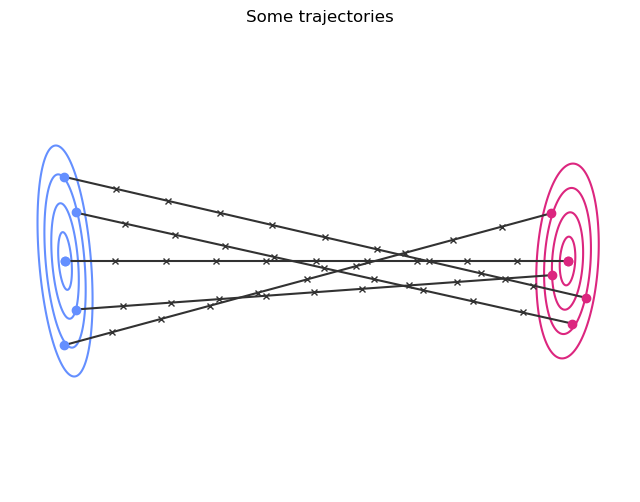

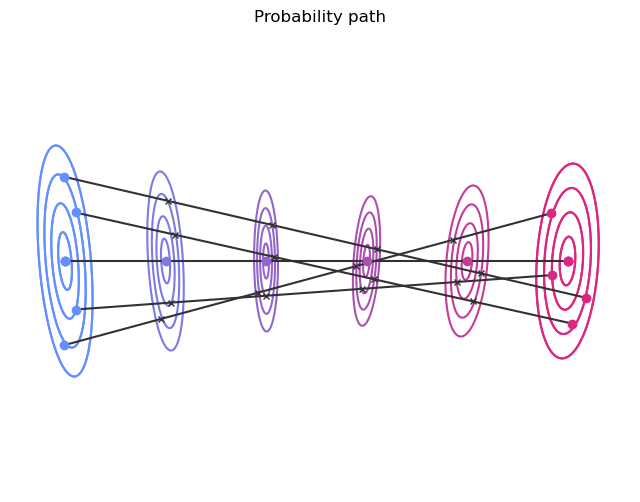

In [18]:
####################################################################
# Dependent case
####################################################################
m0 = np.array([0.0, 0.0])

Sigma0 = np.array(([[ 30., -10.],
                     [-10.,  30.]]))
sqrt_Sigma0 = sqrtm(Sigma0)

b = 200*np.array([1.,0.])
theta=10*np.pi/3
A =np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])

Sigma1 = A.dot(Sigma0).dot(A.T)
m1 = m0+b

Sigma01 = A.dot(Sigma0) #Dependence is provided here

v = lambda t,x : v_Gaussian(t,x,m0,m1,Sigma0,Sigma1,Sigma01)

## Initialization and simulation of the trajectories
nb_traj = 5
n_steps = 100

# For reproduction of the paper figure:
#x0s = m0+sqrt_Sigma0.dot(np.random.randn(2,nb_traj)).T
x0s =np.array([[-.6, -8],[-.6, 8],[ 4.2, -4.6],[ 4.2, 4.6],[0.,0.]])
xts = euler_solver(x0s,v,n_steps=n_steps)


## Visualization of the trajectories
fig, ax = plt.subplots(figsize=(8,6))
for k in range(nb_traj) :
    plt.plot(xts[::10,k,0],xts[::10,k,1],'-x',color=color_trajectories,markersize=4)
    plt.scatter([xts[0,k,0]],[xts[0,k,1]],color=color_source,zorder=2)
    plt.scatter([xts[-1,k,0]],[xts[-1,k,1]],color=color_target,zorder=2)
gaussian_contour(m0, Sigma0, ax=ax, colors=color_source,zorder=1)
gaussian_contour(m1, Sigma1, ax=ax, colors=color_target,zorder=1)
plt.title('Some trajectories')
plt.axis('off')

## Visualization of the probability path
fig, ax = plt.subplots(figsize=(8,6))
for k in range(nb_traj) :
    plt.plot(xts[::20,k,0],xts[::20,k,1],'-x',color=color_trajectories,markersize=4)
    plt.scatter([xts[0,k,0]],[xts[0,k,1]],color=color_source,zorder=2)
    plt.scatter([xts[-1,k,0]],[xts[-1,k,1]],color=color_target,zorder=2)
gaussian_contour(m0, Sigma0, ax=ax, colors=color_source,zorder=1)
gaussian_contour(m1, Sigma1, ax=ax, colors=color_target,zorder=1)
selected_times = np.linspace(0,1,n_steps+1)[::20]
for t in selected_times :
    gaussian_contour( m_t(t,m0,m1), Sigma_t(t,Sigma0,Sigma1,Sigma01), ax=ax, colors=cmap_path(t),zorder=1)
plt.title('Probability path')
plt.axis('off');

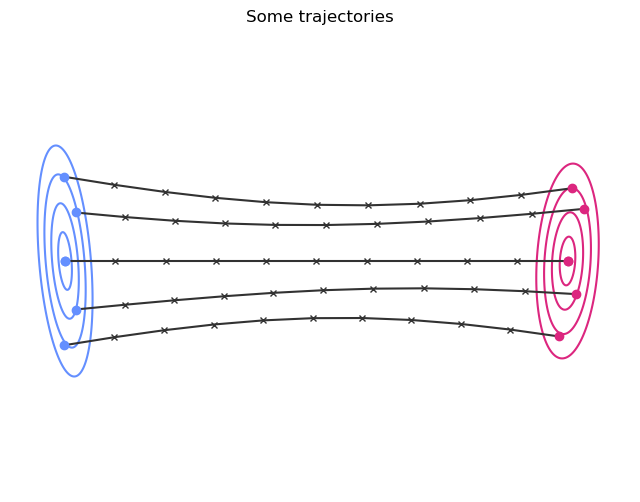

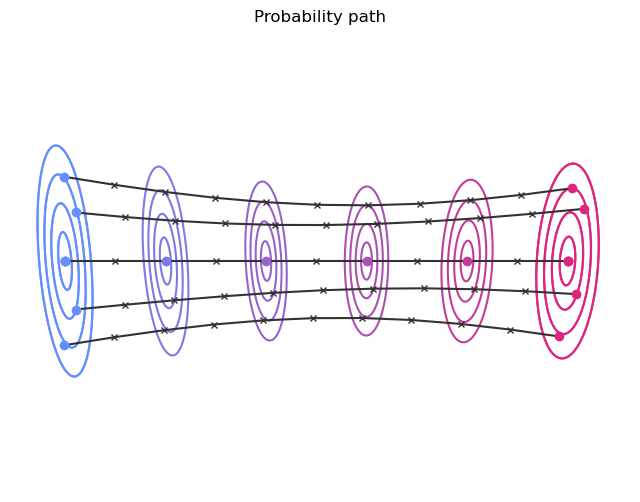

In [19]:
####################################################################
# Independent case
####################################################################
m0 = np.array([0.0, 0.0])

Sigma0 = np.array(([[ 30., -10.],
                     [-10.,  30.]]))
sqrt_Sigma0 = sqrtm(Sigma0)

b = 200*np.array([1.,0.])
theta=10*np.pi/3
A =np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]])

Sigma1 = A.dot(Sigma0).dot(A.T)
m1 = m0+b

Sigma01 = np.zeros((2,2)) #Independence is provided here

v = lambda t,x : v_Gaussian(t,x,m0,m1,Sigma0,Sigma1,Sigma01)

## Initialization and simulation of the trajectories
nb_traj = 5
n_steps = 100

# For reproduction of the paper figure:
#x0s = m0+sqrt_Sigma0.dot(np.random.randn(2,nb_traj)).T
x0s =np.array([[-.6, -8],[-.6, 8],[ 4.2, -4.6],[ 4.2, 4.6],[0.,0.]])
xts = euler_solver(x0s,v,n_steps=n_steps)


## Visualization of the trajectories
fig, ax = plt.subplots(figsize=(8,6))
for k in range(nb_traj) :
    plt.plot(xts[::10,k,0],xts[::10,k,1],'-x',color=color_trajectories,markersize=4)
    plt.scatter([xts[0,k,0]],[xts[0,k,1]],color=color_source,zorder=2)
    plt.scatter([xts[-1,k,0]],[xts[-1,k,1]],color=color_target,zorder=2)
gaussian_contour(m0, Sigma0, ax=ax, colors=color_source,zorder=1)
gaussian_contour(m1, Sigma1, ax=ax, colors=color_target,zorder=1)
plt.title('Some trajectories')
plt.axis('off')

## Visualization of the probability path
fig, ax = plt.subplots(figsize=(8,6))
for k in range(nb_traj) :
    plt.plot(xts[::10,k,0],xts[::10,k,1],'-x',color=color_trajectories,markersize=4)
    plt.scatter([xts[0,k,0]],[xts[0,k,1]],color=color_source,zorder=2)
    plt.scatter([xts[-1,k,0]],[xts[-1,k,1]],color=color_target,zorder=2)
gaussian_contour(m0, Sigma0, ax=ax, colors=color_source,zorder=1)
gaussian_contour(m1, Sigma1, ax=ax, colors=color_target,zorder=1)
selected_times = np.linspace(0,1,n_steps+1)[::20]
for t in selected_times :
    gaussian_contour( m_t(t,m0,m1), Sigma_t(t,Sigma0,Sigma1,Sigma01), ax=ax, colors=cmap_path(t),zorder=1)
plt.title('Probability path')
plt.axis('off');

# Gaussian to a sum of Dirac setting

### Reminder and code of the velocity field formula

As a reminder, if $X_0 \sim \mathcal{N}(0,I)$ and $X_1 = \sum_{k = 0}^n \frac{1}{n} \delta_{x^{(k)}}$,
the velocity field is given by
$$
    v_t(x) = \sum_{k=1}^n \alpha_k(t,x) \frac{x^{(k)}-x}{1-t}
$$
where $\alpha(t,x) = \mathrm{softmax}\left(-\frac{1}{2(1-t)^2}\|x-tx^{(i)}\|^2\right)_{1 \leq i \leq n}$ ie $\alpha_k(t,x) = \displaystyle\frac{e^{-\frac{1}{2(1-t)^2}\|x-tx^{(k)}\|^2}}{\displaystyle\sum_{i=1}^ne^{-\frac{1}{2(1-t)^2}\|x-tx^{(i)}\|^2} }$.

The corresponding code is below.

In [20]:
def softmax(z):
    z = np.asarray(z)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)



def alpha(t, x, X):
    x = np.asarray(x)
    X = np.asarray(X)
    diff = x[:, None, :] - t * X[None, :, :]  
    exponent_terms = -0.5 * np.sum(diff**2, axis=2) / ((1 - t)**2)
    alpha_vals = softmax(exponent_terms)  

    return alpha_vals


def v_Gaussian_to_Dirac(t, x, X):
    alpha_vals = alpha(t, x, X)       
    weighted = alpha_vals[:, :, None] * (X[None, :, :] - x[:, None, :])
    vt = np.sum(weighted, axis=1) / (1 - t) 
    
    return vt

### Illustrative example

Along the probability path, the law of $X_t = t X_1 + (1 - t) X_0$ is a Gaussian mixture with centers $(x^{(k)})_{0 \le k \le n}$ and covariance matrix $(1 - t)^2 I$.

(-4.0, 4.0, -4.0, 4.0)

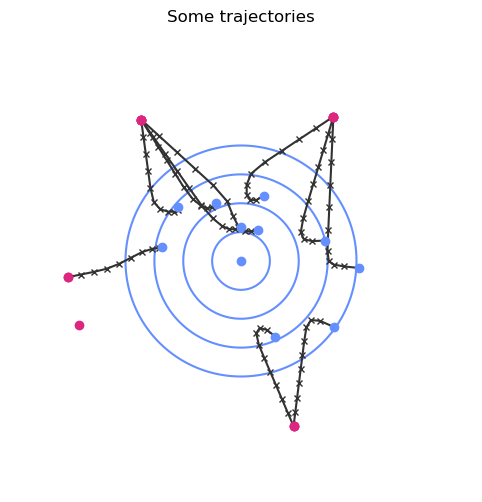

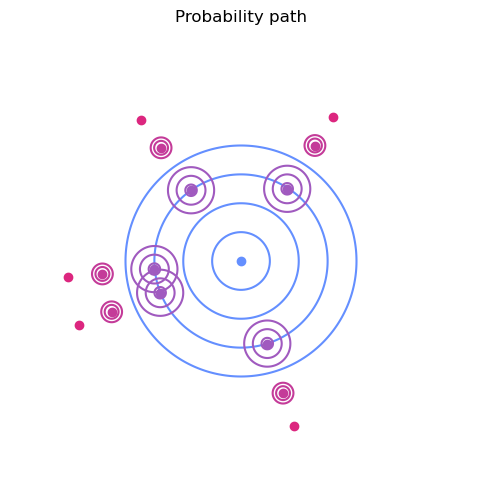

In [22]:
#Source
m0 = np.array([0.0, 0.0])
Sigma0 = np.eye(2)
sqrt_Sigma0 = sqrtm(Sigma0)

#Target
X = np.array([[-3., -0.28],
       [-1.73,  2.45],
       [ 1.6,  2.5],
       [-2.8, -1.1 ],
       [ 0.91, -2.86]])

v = lambda t,x : v_Gaussian_to_Dirac(t,x,X)

#Simulation of trajectories
nb_traj = 10
x0s = m0+sqrt_Sigma0.dot(np.random.randn(2,nb_traj)).T
n_steps = 100
xts = euler_solver(x0s,v,n_steps=n_steps)


## Visualization of the trajectories
fig, ax = plt.subplots(figsize=(8,6))
for k in range(nb_traj) :
    plt.plot(xts[::10,k,0],xts[::10,k,1],'-x',color=color_trajectories,markersize=4)
    plt.scatter([xts[0,k,0]],[xts[0,k,1]],color=color_source,zorder=2)
    plt.scatter([xts[-1,k,0]],[xts[-1,k,1]],color=color_target,zorder=2)
gaussian_contour(m0, Sigma0, ax=ax, colors=color_source,zorder=1)
plt.scatter(X[:,0],X[:,1] ,marker='o',color=color_target)
plt.title('Some trajectories')
plt.axis('off')
plt.axis('scaled')

## Visualization of the probability path
# We reuse the fonctions m_t,Sigma_t from the Gaussian case
fig, ax = plt.subplots(figsize=(8,6))
# Ellipses
gaussian_contour(m0, Sigma0, ax=ax, colors=color_source)
plt.scatter(X[:,0],X[:,1] ,marker='o',color=color_target)
t = .5
lvls = [.2,.5,.8]
for k in range(len(X)) :
    gaussian_contour( m_t(t,m0,X[k]), Sigma_t(t,Sigma0,0*np.eye(2),0*Sigma0), ax=ax, levels=lvls, colors=cmap_path(t))
t=.8
lvls = [.2,.6,.9]
for k in range(len(X)) :
    gaussian_contour( m_t(t,m0,X[k]), Sigma_t(t,Sigma0,0*np.eye(2),0*Sigma0), ax=ax, levels=lvls, colors=cmap_path(t))

ax.set_aspect('equal')
plt.title('Probability path')
plt.axis('off')

# Gaussian mixtures setting

## Independent case

### Reminder and code of the velocity field formula in the independent case

Let
$$
X_0 \sim \sum_{i=1}^{K_0}\pi_i^{(0)}\,\mathcal N\!\big(m_0^{\,i},\Sigma_0^{\,i}\big),
\qquad
X_1 \sim \sum_{j=1}^{K_1}\pi_j^{(1)}\,\mathcal N\!\big(m_1^{\,j},\Sigma_1^{\,j}\big),
$$
be independent Gaussian mixture models with $\pi_i^{(0)}, \pi_j^{(1)} > 0$ and
$\sum_i \pi_i^{(0)} = \sum_j \pi_j^{(1)} = 1$.
Then the conditional mean velocity field $v_t$
can be expressed as
$$
v_t(x) = \sum_{i=1}^{K_0}\sum_{j=1}^{K_1} \alpha_{ij}(x)\, w_t^{ij}(x),
$$
where the posterior weights are given by
$
\alpha_{ij}(x)
= \frac{\pi_i^{(0)}\pi_j^{(1)}\,p_t^{ij}(x)}
{\displaystyle \sum_{a=1}^{K_0}\sum_{b=1}^{K_1}\pi_a^{(0)}\pi_b^{(1)}\,p_t^{ab}(x)},
$
and $p_t^{ij}(x)$ is the density of the Gaussian distribution
$\mathcal N(m_t^{ij}, \Sigma_t^{ij})$ with
$
m_t^{ij} = (1-t)m_0^{\,i} + t\,m_1^{\,j},
$ and $
\Sigma_t^{ij} = (1-t)^2\Sigma_0^{\,i} + t^2\Sigma_1^{\,j}
$.
For each component pair $(i,j)$, the conditional velocity field is
$$
w_t^{ij}(x)
= (m_1^{\,j} - m_0^{\,i})
+ \frac{1}{1-t}
\Big(
t\,\Sigma_1^{\,j}(\Sigma_t^{ij})^{-1} - I
\Big)(x - m_t^{ij})
= \dot{m}_t^{ij}
+ \tfrac{1}{2}\dot{\Sigma}_t^{ij}(\Sigma_t^{ij})^{-1}(x - m_t^{ij}).
$$

In [23]:
def gaussian_pdf(x, mean, cov):
    d = len(x)
    xc = x - mean
    norm = np.sqrt((2*np.pi)**d * np.linalg.det(cov))
    return np.exp(-0.5 * np.sum(xc*np.linalg.solve(cov, xc.T).T,axis=1)) / norm


def w_t_ij(x, i, j, t, m0s, m1s, Sigma0s, Sigma1s):
    mt = m_t(t, m0s[i], m1s[j])
    St = Sigma_t(t, Sigma0s[i], Sigma1s[j],0*Sigma0s[i])

    term1 = m1s[j] - m0s[i]
    term2 = np.linalg.solve(St, (x - mt).T).T   # (N,2)

    return (
        term1
        + t * (term2 @ Sigma1s[j].T)
        - (1 - t) * (term2 @ Sigma0s[i].T)
    )



def alpha_ij(x, t,m0s,m1s,Sigma0s,Sigma1s,pi0,pi1):
    K0 =len(pi0)
    K1 =len(pi1)
    num = np.zeros((x.shape[0],K0, K1))
    for i in range(K0):
        for j in range(K1):
            mt, St = m_t(t,m0s[i],m1s[j]),Sigma_t(t, Sigma0s[i], Sigma1s[j],0*Sigma0s[i])
            num[:,i, j] = pi0[i] * pi1[j] * gaussian_pdf(x, mt, St)
    return num / np.sum(num, axis=(1,2), keepdims=True)




def v_GMM_independents(t,x,m0s,m1s,Sigma0s,Sigma1s,pi0,pi1):
    A = alpha_ij(x, t,m0s,m1s,Sigma0s,Sigma1s,pi0,pi1)
    K0 =len(pi0)
    K1 =len(pi1)
    v = np.zeros((x.shape[0],len(m0s[0])))
    for i in range(K0):
        for j in range(K1):
            v += A[:, i, j][:, None] * w_t_ij(x, i, j, t, m0s, m1s, Sigma0s, Sigma1s)
    return v

### Illustrative examples

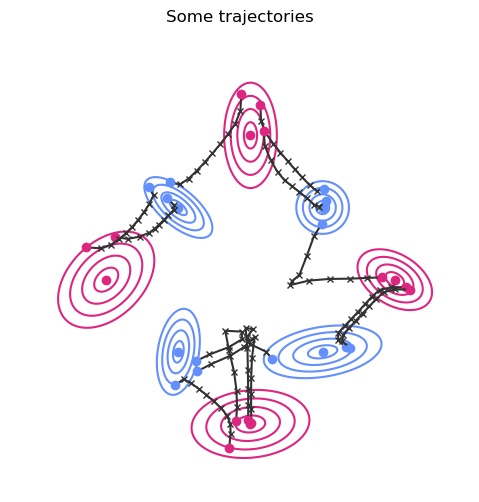

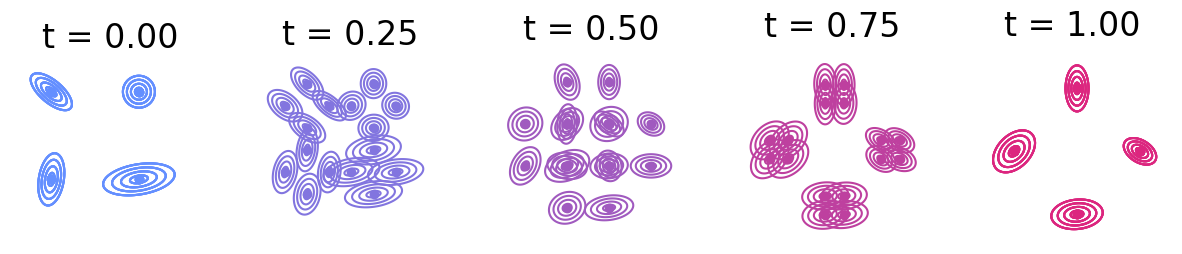

In [24]:
#Source
pi0 = np.array([0.25, 0.25, 0.25, 0.25])
m0s = np.array([
    [-3., -3.],
    [-3.,  3.],
    [ 3., -3.],
    [ 3.,  3.]
])
Sigma0s = np.array([
    [[0.2, 0.1], [0.1, 0.8]],   
    [[0.5, -0.3], [-0.3, 0.4]], 
    [[1.5, 0.2], [0.2, 0.3]],   
    [[0.3, 0.0], [0.0, 0.3]]  
])

# Target
pi1 = np.array([0.25, 0.25, 0.25, 0.25])
m1s = np.array([
    [-6.,  0.],
    [ 0.,  6.],
    [ 6.,  0.],
    [ 0., -6.]
])
Sigma1s = np.array([
    [[1.0, 0.4], [0.4, 1.0]],  
    [[0.3, 0.0], [0.0, 1.2]], 
    [[0.6, -0.2], [-0.2, 0.4]], 
    [[1.5, 0.1], [0.1, 0.5]]   
])

K0 = len(pi0)
K1 = len(pi1)



v = lambda t,x : v_GMM_independents(t,x,m0s,m1s,Sigma0s,Sigma1s,pi0,pi1)


x0s = []
for k in range(K0):
    for _ in range(3):
        x0s.append(np.random.multivariate_normal(m0s[k], Sigma0s[k]))
x0s = np.array(x0s)
n_steps=1000
xts = euler_solver(x0s,v,n_steps=n_steps)

fig, ax = plt.subplots(figsize=(8,6))
for i in range(len(pi0)):
    gaussian_contour(m0s[i], Sigma0s[i], ax=ax, colors=color_source)
    
for i in range(len(pi1)):
    gaussian_contour(m1s[i], Sigma1s[i], ax=ax, colors=color_target)

for k in range(len(x0s)) :
    plt.plot(xts[::100,k,0],xts[::100,k,1],'-x',color=color_trajectories,markersize=4)
    plt.scatter([xts[0,k,0]],[xts[0,k,1]],color=color_source,zorder=2)
    plt.scatter([xts[-1,k,0]],[xts[-1,k,1]],color=color_target,zorder=2)

plt.axis('scaled')
plt.axis('off')
plt.title('Some trajectories')

## Probability path

ts = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, len(ts), figsize=(15, 4))

for ax, t in zip(axes, ts):

    ax.set_title(f"t = {t:.2f}", fontsize=24, pad=0)

    # mixture intermédiaire : K0*K1 composantes
    for i in range(K0):
        for j in range(K1):
            mt, St = m_t(t,m0s[i],m1s[j]),Sigma_t(t, Sigma0s[i], Sigma1s[j],0*Sigma0s[i])
            gaussian_contour( mt, St,ax, colors=cmap_path(t))

    ax.axis('scaled')
    ax.axis('off')


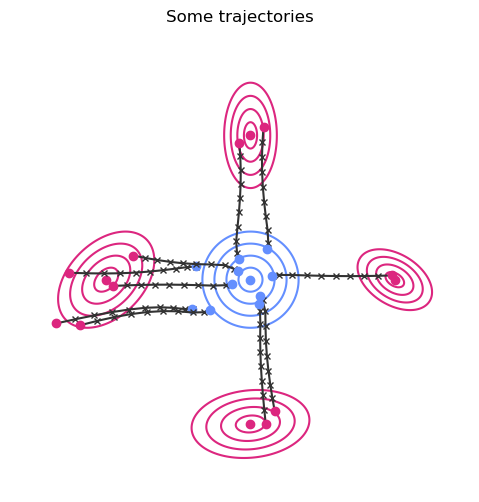

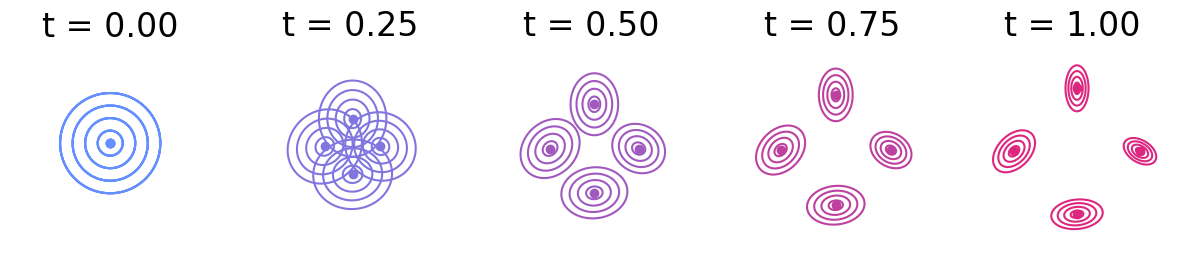

In [27]:

pi0 = np.array([1])
m0s = np.zeros((1,2))
Sigma0s = np.array([np.eye(2)])

# Target
pi1 = np.array([0.25, 0.25, 0.25, 0.25])
m1s = np.array([
    [-6.,  0.],
    [ 0.,  6.],
    [ 6.,  0.],
    [ 0., -6.]
])
Sigma1s = np.array([
    [[1.0, 0.4], [0.4, 1.0]],  
    [[0.3, 0.0], [0.0, 1.2]], 
    [[0.6, -0.2], [-0.2, 0.4]], 
    [[1.5, 0.1], [0.1, 0.5]]   
])

K0 = len(pi0)
K1 = len(pi1)



v = lambda t,x : v_GMM_independents(t,x,m0s,m1s,Sigma0s,Sigma1s,pi0,pi1)


x0s = []
for k in range(K0):
    for _ in range(10):
        x0s.append(np.random.multivariate_normal(m0s[k], Sigma0s[k]))
x0s = np.array(x0s)
n_steps=1000
xts = euler_solver(x0s,v,n_steps=n_steps)

fig, ax = plt.subplots(figsize=(8,6))
for i in range(len(pi0)):
    gaussian_contour(m0s[i], Sigma0s[i], ax=ax, colors=color_source)
    
for i in range(len(pi1)):
    gaussian_contour(m1s[i], Sigma1s[i], ax=ax, colors=color_target)

for k in range(len(x0s)) :
    plt.plot(xts[::100,k,0],xts[::100,k,1],'-x',color=color_trajectories,markersize=4)
    plt.scatter([xts[0,k,0]],[xts[0,k,1]],color=color_source,zorder=2)
    plt.scatter([xts[-1,k,0]],[xts[-1,k,1]],color=color_target,zorder=2)

plt.axis('scaled')
plt.axis('off')
plt.title('Some trajectories')

## Probability path

ts = [0.0, 0.25, 0.5, 0.75, 1.0]
fig, axes = plt.subplots(1, len(ts), figsize=(15, 4))

for ax, t in zip(axes, ts):

    ax.set_title(f"t = {t:.2f}", fontsize=24, pad=0)

    # mixture intermédiaire : K0*K1 composantes
    for i in range(K0):
        for j in range(K1):
            mt, St = m_t(t,m0s[i],m1s[j]),m_t(t,Sigma0s[i],Sigma1s[j])
            gaussian_contour( mt, St,ax, colors=cmap_path(t))

    ax.axis('scaled')
    ax.axis('off')
